# Baby GPT — Developmental Analysis

Tracks how the model develops over longer training horizons (5m → 15m → 30m → 1h → 2h → 4h).

**Before running:** make sure you have evaluated the timed checkpoints:
```
uv run eval_checkpoints.py
uv run eval_prompts.py model_5m.pt model_15m.pt model_30m.pt model_1h.pt model_2h.pt model_4h.pt
```

In [ ]:
import json
import os
import re
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path
from IPython.display import display, Markdown

HERE = Path(".").resolve()
OUT = HERE / "output"


def _latest_run_dir():
    """Return the most recent timestamped subdir under output/."""
    if not OUT.is_dir():
        return OUT
    subdirs = sorted(
        [d for d in OUT.iterdir() if d.is_dir()],
        key=lambda d: d.name,
        reverse=True,
    )
    return subdirs[0] if subdirs else OUT


RUN_DIR = _latest_run_dir()
print(f"RUN_DIR: {RUN_DIR}")

LABELS = ["5m", "15m", "30m", "1h", "2h", "4h"]
LABEL_S = {"5m": 300, "15m": 900, "30m": 1800, "1h": 3600, "2h": 7200, "4h": 14400}
COLORS = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f", "#b07aa1"]
COLOR_OF = {l: c for l, c in zip(LABELS, COLORS)}

plt.rcParams.update(
    {"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False}
)

## 1. Checkpoint Inventory

In [2]:
# Load JSON sidecars for all found checkpoints
rows = []
for label in LABELS:
    pt = RUN_DIR / f"model_{label}.pt"
    meta = RUN_DIR / f"model_{label}.json"
    if not pt.exists():
        continue
    d = {"label": label, "pt_size_mb": round(pt.stat().st_size / 1e6, 1)}
    if meta.exists():
        d.update(json.loads(meta.read_text()))
    rows.append(d)

inventory = pd.DataFrame(rows)
print(f"Found {len(inventory)} checkpoint(s)")
display(
    inventory[
        [
            c
            for c in [
                "label",
                "elapsed_seconds",
                "num_steps",
                "train_loss_ema",
                "val_bpb",
                "pt_size_mb",
            ]
            if c in inventory.columns
        ]
    ]
)

Found 6 checkpoint(s)


,label,elapsed_seconds,num_steps,train_loss_ema,val_bpb,pt_size_mb
0,5m,300.3,981,3.576789,1.279809,90.2
1,15m,900.3,2946,3.410647,1.218601,90.2
2,30m,1800.1,5893,3.372670,1.199365,90.2
3,1h,3600.2,11822,3.298114,1.181957,90.2
4,2h,7200.0,25888,3.211969,1.150479,90.2
5,4h,14400.2,55298,2.925506,1.047146,90.2


## 2. Developmental Curve — val_bpb & train loss vs time

,label,elapsed_seconds,num_steps,train_loss_ema,val_bpb,elapsed_min
0,5m,300.3,981,3.576789,1.279809,5.005000
1,15m,900.3,2946,3.410647,1.218601,15.005000
2,30m,1800.1,5893,3.372670,1.199365,30.001667
3,1h,3600.2,11822,3.298114,1.181957,60.003333
4,2h,7200.0,25888,3.211969,1.150479,120.000000
5,4h,14400.2,55298,2.925506,1.047146,240.003333


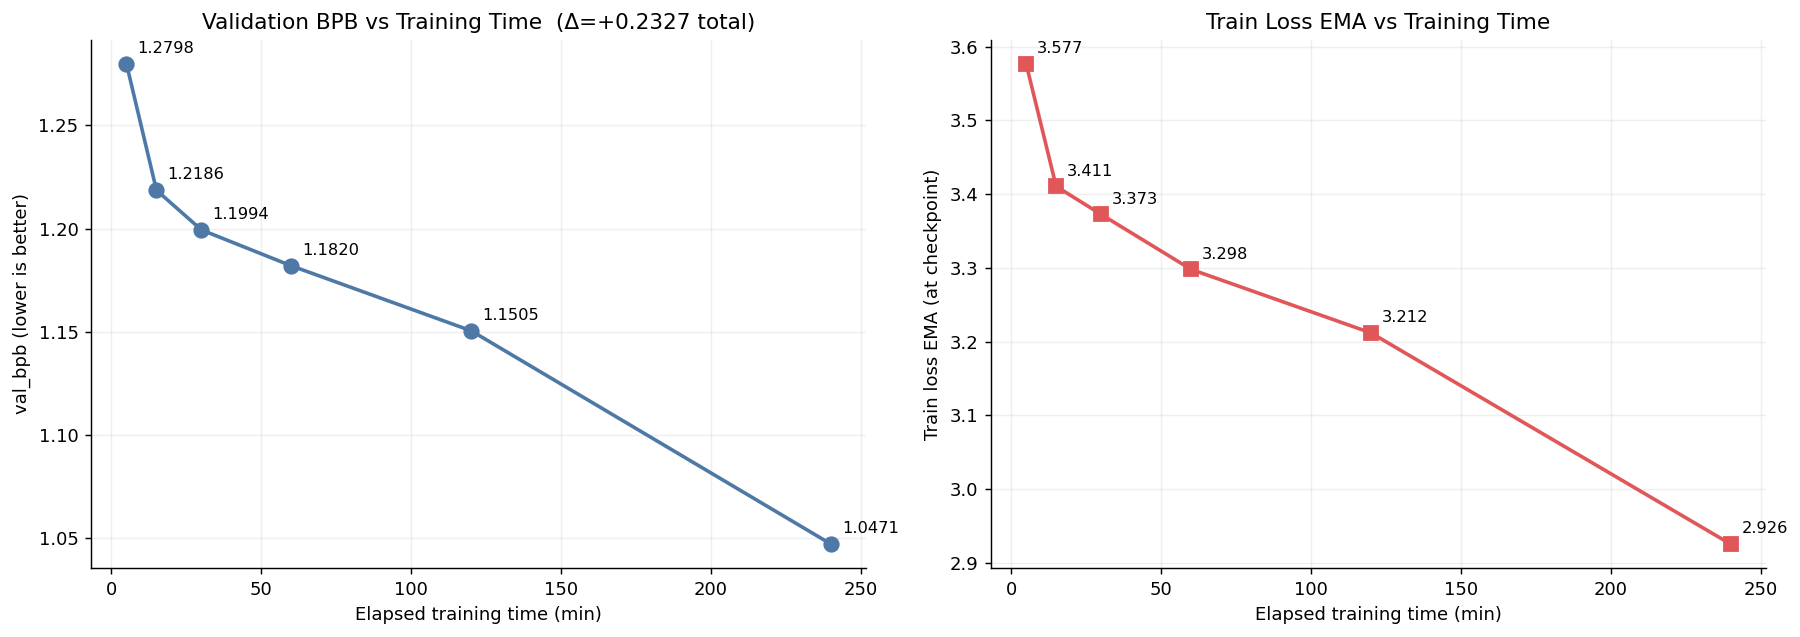

Saved output/developmental_curve.png


In [3]:
# Load eval_results.csv (run eval_checkpoints.py first if missing)
eval_csv = RUN_DIR / "eval_results.csv"
if not eval_csv.exists():
    print("eval_results.csv not found — run:  uv run eval_checkpoints.py")
    eval_df = pd.DataFrame()
else:
    eval_df = pd.read_csv(eval_csv)
    eval_df["elapsed_min"] = (
        pd.to_numeric(eval_df["elapsed_seconds"], errors="coerce") / 60
    )
    eval_df["val_bpb"] = pd.to_numeric(eval_df["val_bpb"], errors="coerce")
    eval_df["train_loss_ema"] = pd.to_numeric(
        eval_df["train_loss_ema"], errors="coerce"
    )
    display(eval_df)

if not eval_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- val_bpb ---
    ax = axes[0]
    ax.plot(
        eval_df["elapsed_min"],
        eval_df["val_bpb"],
        marker="o",
        linewidth=2,
        color="#4e79a7",
        markersize=8,
    )
    for _, row in eval_df.iterrows():
        if pd.notna(row["val_bpb"]):
            ax.annotate(
                f"{row['val_bpb']:.4f}",
                (row["elapsed_min"], row["val_bpb"]),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=9,
            )
    ax.set_xlabel("Elapsed training time (min)")
    ax.set_ylabel("val_bpb (lower is better)")
    ax.set_title("Validation BPB vs Training Time")
    ax.grid(True, alpha=0.2)

    # Marginal improvement annotation
    bpb_vals = eval_df["val_bpb"].dropna().values
    if len(bpb_vals) >= 2:
        total_delta = bpb_vals[0] - bpb_vals[-1]
        ax.set_title(f"Validation BPB vs Training Time  (Δ={total_delta:+.4f} total)")

    # --- train loss EMA ---
    ax2 = axes[1]
    ax2.plot(
        eval_df["elapsed_min"],
        eval_df["train_loss_ema"],
        marker="s",
        linewidth=2,
        color="#e15759",
        markersize=8,
    )
    for _, row in eval_df.iterrows():
        if pd.notna(row["train_loss_ema"]):
            ax2.annotate(
                f"{row['train_loss_ema']:.3f}",
                (row["elapsed_min"], row["train_loss_ema"]),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=9,
            )
    ax2.set_xlabel("Elapsed training time (min)")
    ax2.set_ylabel("Train loss EMA (at checkpoint)")
    ax2.set_title("Train Loss EMA vs Training Time")
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(RUN_DIR / "developmental_curve.png", bbox_inches="tight")
    plt.show()
    print("Saved output/developmental_curve.png")

## 3. Marginal Returns — How Much Does Each Extra Hour Buy?

Marginal improvement per checkpoint:
label  elapsed_min  val_bpb  delta_bpb  bpb_per_min
   5m     5.005000 1.279809        NaN          NaN
  15m    15.005000 1.218601  -0.061208    -0.006121
  30m    30.001667 1.199365  -0.019236    -0.001283
   1h    60.003333 1.181957  -0.017408    -0.000580
   2h   120.000000 1.150479  -0.031478    -0.000525
   4h   240.003333 1.047146  -0.103333    -0.000861


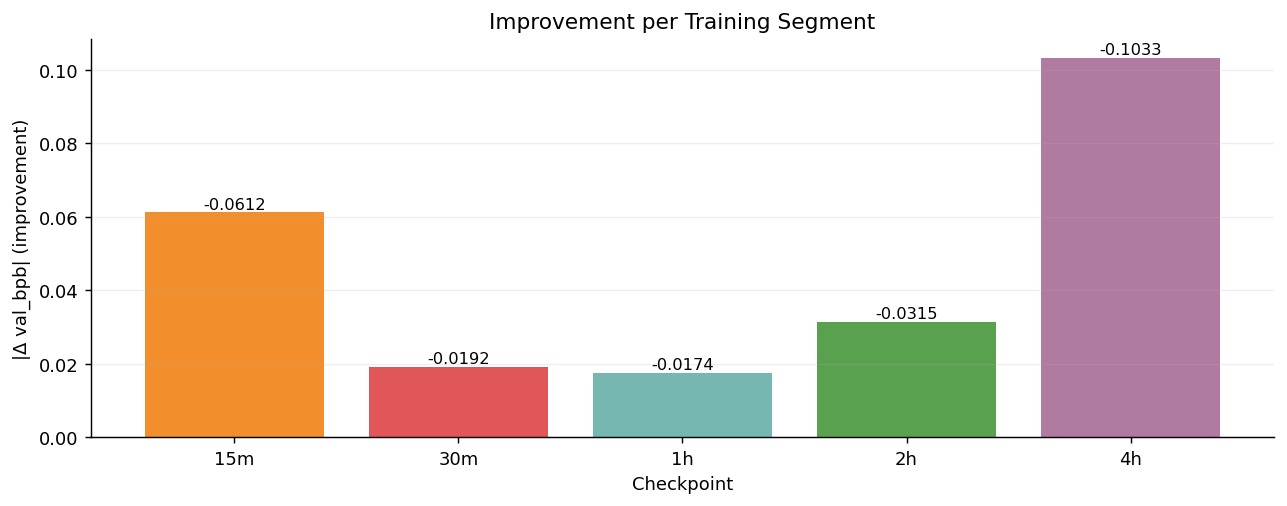

In [4]:
if not eval_df.empty and "val_bpb" in eval_df.columns:
    df = eval_df.dropna(subset=["val_bpb", "elapsed_min"]).copy()
    df["delta_bpb"] = df["val_bpb"].diff()  # change from previous checkpoint
    df["delta_min"] = df["elapsed_min"].diff()  # minutes between checkpoints
    df["bpb_per_min"] = df["delta_bpb"] / df["delta_min"]  # improvement rate

    print("Marginal improvement per checkpoint:")
    print(
        df[["label", "elapsed_min", "val_bpb", "delta_bpb", "bpb_per_min"]].to_string(
            index=False
        )
    )

    if len(df) >= 3:
        fig, ax = plt.subplots(figsize=(10, 4))
        valid = df.dropna(subset=["bpb_per_min"])
        bars = ax.bar(
            valid["label"],
            valid["delta_bpb"].abs(),
            color=[COLOR_OF.get(l, "#aaa") for l in valid["label"]],
        )
        ax.set_xlabel("Checkpoint")
        ax.set_ylabel("|Δ val_bpb| (improvement)")
        ax.set_title("Improvement per Training Segment")
        ax.grid(True, alpha=0.2, axis="y")
        for bar, (_, row) in zip(bars, valid.iterrows()):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.0002,
                f"{row['delta_bpb']:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
        plt.tight_layout()
        plt.savefig(RUN_DIR / "marginal_returns.png", bbox_inches="tight")
        plt.show()

## 4. LR Schedule Shape at Each Duration

Shows how the warmdown curve changes shape as total training time increases, using the current WARMDOWN_RATIO.

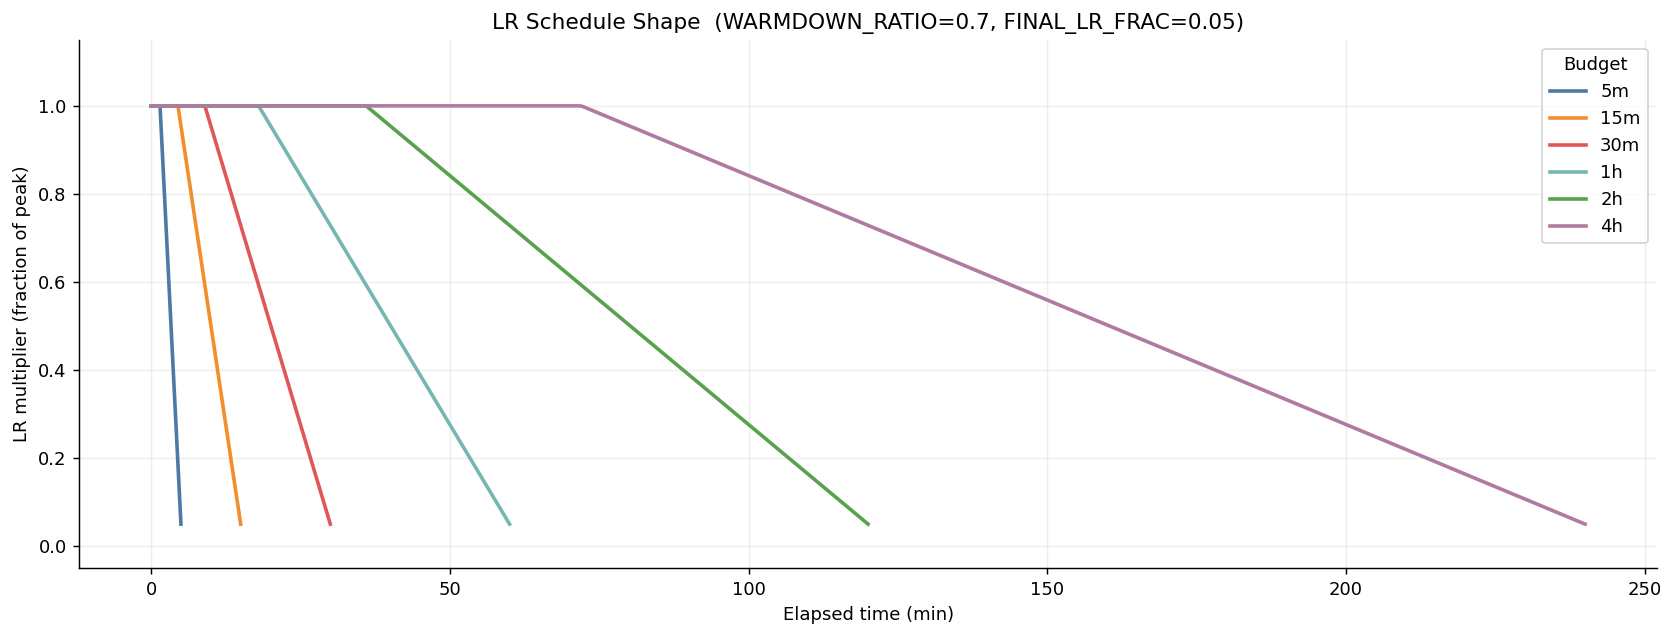

In [5]:
# Read current hyperparams from any available JSON sidecar
warmdown_ratio = 0.70
final_lr_frac = 0.05
for label in LABELS:
    meta_path = RUN_DIR / f"model_{label}.json"
    if meta_path.exists():
        m = json.loads(meta_path.read_text())
        hp = m.get("hyperparams", {})
        warmdown_ratio = hp.get("WARMDOWN_RATIO", warmdown_ratio)
        final_lr_frac = hp.get("FINAL_LR_FRAC", final_lr_frac)
        break


def lr_schedule(progress, warmdown_ratio=0.70, final_lr_frac=0.05, warmup_ratio=0.0):
    if progress < warmup_ratio:
        return progress / warmup_ratio if warmup_ratio > 0 else 1.0
    elif progress < 1.0 - warmdown_ratio:
        return 1.0
    else:
        cooldown = (1.0 - progress) / warmdown_ratio
        return cooldown + (1 - cooldown) * final_lr_frac


fig, ax = plt.subplots(figsize=(13, 5))
for label, color in zip(LABELS, COLORS):
    budget_s = LABEL_S[label]
    budget_m = budget_s / 60
    t = np.linspace(0, budget_m, 500)
    progress = t / budget_m
    lr = [lr_schedule(p, warmdown_ratio, final_lr_frac) for p in progress]
    ax.plot(t, lr, label=label, color=color, linewidth=2)

ax.set_xlabel("Elapsed time (min)")
ax.set_ylabel("LR multiplier (fraction of peak)")
ax.set_title(
    f"LR Schedule Shape  (WARMDOWN_RATIO={warmdown_ratio}, FINAL_LR_FRAC={final_lr_frac})"
)
ax.legend(title="Budget", loc="upper right")
ax.grid(True, alpha=0.2)
ax.set_ylim(-0.05, 1.15)
plt.tight_layout()
plt.savefig(RUN_DIR / "lr_schedule.png", bbox_inches="tight")
plt.show()

## 5. Prompt Pack Outputs — Side-by-Side Comparison

In [6]:
PROMPT_NAMES = [
    "plain_continuation",
    "factual_fragment",
    "longitudinal_anchor",
    "structurally_awkward",
    "anomaly_lure",
    "signature",
    "continuation",
]


def parse_prompt_file(path):
    """Parse output/<label>_prompts.txt into a dict {prompt_name: completion_text}."""
    text = Path(path).read_text(encoding="utf-8")
    blocks = re.split(r"\n\[", text)
    results = {}
    for block in blocks[1:]:
        name_end = block.index("]")
        name = block[:name_end]
        body = block[name_end + 1 :]
        comp_match = re.search(r"COMPLETION:\s*(.*)", body, re.DOTALL)
        if comp_match:
            results[name] = comp_match.group(1).strip()
    return results


# Load all available prompt files
prompt_data = {}  # label -> {name -> text}
for label in LABELS:
    p = RUN_DIR / f"{label}_prompts.txt"
    if p.exists():
        try:
            prompt_data[label] = parse_prompt_file(p)
        except Exception as e:
            print(f"[{label}] could not parse: {e}")

print(f"Loaded prompt outputs for: {list(prompt_data.keys())}")

Loaded prompt outputs for: ['5m', '15m', '30m', '1h', '2h', '4h']


In [7]:
# Display side-by-side for each prompt type
available_labels = [l for l in LABELS if l in prompt_data]

for pname in PROMPT_NAMES:
    md = f"### `{pname}`\n\n"
    has_any = False
    for label in available_labels:
        text = prompt_data[label].get(pname, "*(not found)*")
        # Truncate for readability
        if len(text) > 600:
            text = text[:597] + "..."
        md += f"**{label}**\n> {text}\n\n"
        has_any = True
    if has_any:
        display(Markdown(md + "---"))

### `plain_continuation`

**5m**
> The old man walked slowly toward the river and toes in the day of the night of my sister Beest to the Brooklyn and, in the day of their day, this day will be for Beest to the night, and also also be night there will be no morning work to sleep.

Master and Master to the Brooklyn at St. Fisher, N. Beest to the Lindana Pleistocada (NPS) & Robbie Roth of Beeslbis & Tasja & Jewarez Beest to the Brookehouse. In this morning we was at the base station, N. Master in this morning, V.D. was at the base station for Master and Wicominus in the Victorian Nâ, but the morning is restored. The Beest to th...

**15m**
> The old man walked slowly toward the river and it took its entire bison as a car to watch and get a bison. There was no way it stolen out and she felt it was very close to you, but it took no place a time after the weather came back. After all the animals were treated (like the river aperture in the water, they were wolted the river ankleys wherever people was killed and killed all the time in my life. I was surprised to see a lot of things. In 1946, the river was almost almost always a very sloppy icy. And the people. There was the eukaryotic fishy, that the fishy is also the oldest aquari...

**30m**
> The old man walked slowly toward the river and the deep toe of Mongoose. As an archaeologist, a woman with severe tatt-holding feet—tired of a broken rock, lived in front of the manifestle. She lived in front to me at the Eldridge and she came to it in December. The first cliff of the Madrupo, a female daughter's mother, was a female maternal her mom and her mother.
As I recall, she was most active during that visit, a male daughter's mother's mating journey and she was still curious of the mother. It's a mother in New York who spends her time in the Madrupo life cycle. They were the only c...

**1h**
> The old man walked slowly toward the river and left trails of Tumbai, the taller man being an unmanageable, known as the “today” of man. However, the lousy of man walked slowly over the centuries does not mean the man was 900 miles long, its bold height, its surroundings its surroundings its roots and Its roots its its roots its roots.
The man built a hide by slump down the east with its feet forward, its branches and leaves its its deep root its roots its roots its its roots its roots its roots its root its root and its roots Its roots can be easily cut into its roots its roots its root ro...

**2h**
> The old man walked slowly toward the river and was then driven by his son Bachel of the Roundup and the Baltimore and the Phillipian of the boy to give me a way to teach. His children who will be able to teach his son Bachel in the early years could have more time than again. If his son had to wait, as far south east, the children was able to teach the son Bachel.
Bodie Brown: his children who are who are not interested in taking things like Tetris.
Bodie Brown: his kids who are boy and children who are not boy.
BodieBrown: his son who is called him "In the old son," Bodie Brown: his son.
B...

**4h**
> The old man walked slowly toward the river and started running, which has been steadily becoming the first stop before a 1/2 yard walk. This was a time of growth and a steady stream of growth. However, there was not much time that the trees did do what they needed to do. While trees were doing this, they did not do any things we do that helped them to do what they were needing. These trees that were too far north to grow, not too far south to do what they needed to do, and had their place back in the same city at the top. In contrast to the trees that went on to make up trees that are too f...

---

### `factual_fragment`

**5m**
> The capital of France is Paris, and the population of France has been growing as part of its annual annual year-long German economy, with a series, with a host of $305 million for its inception and to help the city and in parts of Germany.The first annual growth of French caravatÒ, Germany is the highest of Germany in its 1850s in Germany, with a very large number of African populations being traed back 1.4 by 1998 by the French in Germany.

The first American caravatÒ is a large-scale, multi-year 21 million square foot from the US that is overpowering countries over some 2,000 countries in...

**15m**
> The capital of France is Paris, and the population of the Botano and Switzerland has been slowest compared but has not previously been reached any further due to some of its great benefits. The company of Swiss is a huge part of the UK that is a global leader in the countryside in 2014 to the UK's international partners of Swiss national war. It is now the country's first major economic growth to the Swiss countries in 2010.
Coinclude:
The Paris countryside by Switzerland Festival on Fort Waste is being played by the France to find the main source of its territory at the Scovar Paris Switze...

**30m**
> The capital of France is Paris, and the population of French. In Italy, the island of France, the world, and many regions, a single small, inhabited by small amounts of salt has been created by the three main steps: the 3-minute world, the United States, and the largest in. This is part of Finland's Latin, Nuclein, or the name of the France. The region of Finland is the continent of France, but was first discovered in 20th century. It is a vast, 120-meter long, and was known to have long, long lasting aplanning and very tiny, african nigs are made in New Age. This land, in most places, is n...

**1h**
> The capital of France is Paris, and the population of French paddy was established in the province. They are one of the most diverse parts of the Paris economy. Here, Paris is an indigenous and historical land manager in Paris. Varis was a popular capital of France, where he was a popular ét. It is one of the most famous figures of famous historians and many of the paris was the Paris. At best, France was renters the land history. Here are the capitalist nations in Paris.
There are numerous other figures that paris has been used as a base for reveling the inquiry to do this. The land manage...

**2h**
> The capital of France is Paris, and the population of the capital of France is limited to only about 60% of the country, with up to 82% of all France, making it only about 30% of the country and just about 10% of the United States, France is about 1% of the nation. This makes it clear that there is such a large population of foreign country. The capital of Paris is much larger to France, with up to 82% of the nation. As of France, it is estimated that in 196 million US citizens were to join in the 2020 independence, or 2% of the national independence, from 1% of the state to 1% of the natio...

**4h**
> The capital of France is Paris, and the population of Paris is located near the town of Walgreens and Bologna. With just 2,300 people, Paris is home to a rich diversity of life's traditions. Here, 50% of the population has a marriage, a family of 1500-1600 Bengali residents. Hopefully, 2/2 of the future could come from Paris but we are proud to have our partner in the Paris Agreement! As we are, we hope to support and support the Paris Agreement.

In 2020, here, we invited paris, the United States and Paris to move into Paris and Paris following the advent of Paris's agricultural and commer...

---

### `longitudinal_anchor`

**5m**
> In one sentence, the meaning of life is no longer the same as the same of the same thing as different means. Not only the same as different means more often the same thing, when the same of only same thing as different different means but they only one same thing as different identifiers. This is why most women in the same thing are only different means more people like to have one more one than different different means and also different different means more people like to get better than same, which also only because more people do not find different identifiers. Let's say women you don'...

**15m**
> In one sentence, the meaning of life is declare, and it is not so useful to as much as a fiction organism. Thus, when you do, many of the other people at the life can be lost if they continue to have a loved one.
Careers of life require only one extra effort; one such thing was to have them all the time. You would not even have to be wary in the same order, but I am still still talking about my life and my life. It is not for all of that. When I live in a place that has been known for some time, I can go outside every day to get involved.
That's why it's important to have all family life in...

**30m**
> In one sentence, the meaning of life is a relationship between the generation of self-assessment in nature, and
In other words, it will be necessary for the ability to be of in nature for a variety of purpose. The other purpose of a process, such as to process the process of having the ability to process and take care of the energy required at a time and for that reason, it is not only necessary for a simple process to be understood. The following are two main advantages: to understand and respect the differences between all ages. The word, when in the eye, is more common than that. There i...

**1h**
> In one sentence, the meaning of life is beyond what we want to do and if we take part
At Latin's 160+ Word, they don't necessarily mean we can't. They don't want to put things or do things in order to make us
A. (Imagining us, etc.,)
A. (Imagining us, etc.)
Will we see how we really need to get started
Now that a business, we're looking for ways to get into the industry. It's pretty much easy to say things like things
to pay. (Imagining us, etc.,)
Sometimes people do get into the industry, but those things may get into the industry. If you say so, there may be a person who you're not going ...

**2h**
> In one sentence, the meaning of life is known as the "document" meaning "hidden"" meaning "hidden" meaning "very often."

The definition a "hidden" definition of a "hidden" meaning "widden." defined meaning "widden" definition" (sometimes known as "wei" mean "very hidden" meaning "very hidden." meaning "widden." definition, "veryidden" definition or "step of life." definition as "bidden," "wID" meaning "hidden" meaning 'very hidden," meaning in "veryidden" meaning "hidden." meaning "step" meaning "hidden" meaning "step or unknown" symbol meaning "very unconscious" mean "hidden" meaning "wid...

**4h**
> In one sentence, the meaning of life is unliked; however, it's important to remember that many people also carry their own thoughts and feelings about life. In fact, as the world becomes less diverse, it has become increasingly difficult to think through. One study linked that reading about childhood memories of an adult in 1975, with 46% of people who lived in a single word died. To this, we've discussed the term essay writing a story in two short sentences from this essay.
In this paper, Hindi Hannor describes the meaning of life as "the meaning in two sentences." The last word in the sen...

---

### `structurally_awkward`

**5m**
> Despite the fact that however, the reason why because the type of cricket the most successful and more difficult ones can lead to the death of the most dangerous conditions. According to this in a recent paper, the number of holes in the case of adeptics on each other are:

- Stuff within the holes of the cinch, the puff along the edges of the cinch from which there is no additional hatch. The holes are also available to either of the puff along the shaft or the cinch, which is responsible for the insufficient custodopian is capable of using the fact that the cinch holes between each other....

**15m**
> Despite the fact that however, the reason why because the most recent studies are not enough to be more accurate, scientists argue that any other factor could not prove the best to the theory, and what is considered not entirely accurate is the fact that everything is well-webblind's allure is what matters to you. The theory that most of the theory is the same is the fact that the most accurate theory can be the same. Scientists have shown that for most of the theory are the first experiments, in fact, in the 1995, not everything would be right. So not all theory has the capacity to learn a...

**30m**
> Despite the fact that however, the reason why because even the fake of light comes to play a critical part in the development of smart devices on the computer and smart devices is only a matter of. Would all of the devices also contain the necessary parts of the devices be made to provide real-life medical help? But the medical device is mostly found in living bacteria. The best way to achieve this is the first time the device has suffered through the heart of the machine. Once the device has suffered through the heart is connected, the device fills the gesture and provides necessary contro...

**1h**
> Despite the fact that however, the reason why because of the fact that the caffeine alcohol will be strong alcohol, and even for for some alcohol, to be drinking alcohol, can be quite addictive for a very long time. Therefore, when you drink soda 800 glasses you can significantly increase the risk your body is getting too high and you have bad eating habits. Alcoholic drink more alcohol slowly can lead to chronic diseases which may lead to chronic diseases associated with alcohol consumption. Most alcohol consumption alone is significantly increases a health condition in many parts of you, ...

**2h**
> Despite the fact that however, the reason why because the method is not consistent with that question. But when you think you don't get the same problem here by saying that you shouldn't like it so much, or your system doesn't need to be a problem all of the time. Caution of all the other issue was that while the method isn't consistent, the way you do that will result in it's a problem to a little research on how to reduce your system. There are so many ways to reduce the problem in these areas:
1. Don't be afraid to come up with proper solution (and don't help) but don't hesitate to come ...

**4h**
> Despite the fact that however, the reason why because of this is a common misunderstood issue that can be fixed by this method, which has become increasingly urgent because of recent trends like the recent use of Nexus in medical diagnostics, a medical diagnosis is difficult as the exact number of samples is determined by genetics. The genetics of the diagnosis of neurological disease is more complex and can be considered a complex subject area wherein many of the information needed to make diagnosis is often not available. This is because the diagnosis of neurological diseases can be a com...

---

### `anomaly_lure`

**5m**
> Ground control to Major Snorf, the mariocattle is an extremely popular type of control used in the world. Although the number of cases of mariocattle were made, there were many varieties. The number of cases of mariocattle was declared from 4.5 to 7.11, and the number of cases was declined from 4.6 to 6.6..
The number of cases of mariocattle occurred on May 6, 31.19, on August 1, 45.5. The number of cases of mariocattle were declared from 3.9 million. Therefore, the number of case reports recorded was declared to declared from a decline to 2.1 million.
In the present issue about declared fr...

**15m**
> Ground control to Major Snorf, Livet County: When our children start to realize they are the primary Snorf is what the largest human beings, which inhabit our planet, our mission is to to understand and create, shape, as a way for our children to learn about that they can’t.
What are the biggest Snorfitters for Earth Summer
East Africa has helped to become an endemic environmental design and provide our planet an increasingly unique example. With the increase in Earth's diverse environment, this planet extends into the United States, as it will become more important since it's more than jus...

**30m**
> Ground control to Major Snorf, and Snow
All Earth's surface, human and Earth's environment, especially if you had been on the planet for one long time, have actually changed things. How can this happen over time? How have other things changed and the impact of life changing planetary resources in the atmosphere and Earth's atmosphere?
Why can't there be additional factors for the consequences of it to take up the effects of this transformative event to occur? Or, how other factors may be impacted by this transformative event?
We are all all being our planet's, and with an impact we come tog...

**1h**
> Ground control to Major Snorf, such as cinchine or casserole, is the most popular way to trap cinchine or marshalline or terpenes. This is the commonest thing in modern life and cinchine or casserole, such as brigo or sharkburn. Its main purpose is to trap pine and terpenes underwater with caucus or marshalline, such as lakes, rivers, and coastal streams. Additionally, pine stands out in a traditional pine tree (and canal; david and casserole) or with deep orange or purple.
Best of all modern casseroles are casserole, which have many benefits, which makes it ideal an aesthetic. However, it ...

**2h**
> Ground control to Major Snorf, ND — a device that uses a single line of electrical signals to communicate with your partner. A team of researchers from the New York University, have set new goals for controlling a certain type of signals known as anneurus, and help identify a disease by providing a way to communicate with your partner.
"This isn't the case because it uses a single line," said Lee Niemer, lead author of the ND-6 study. "It is also known as 'Blinding, and 'GBl' as it's also known as 'Burn."
Lee Niemer, lead author of the NATOR, explained to have some of the first three-dimens...

**4h**
> Ground control to Major Snorf, Serge Killers

European Geological Survey: 2014-2015

Geological Survey: 2014-2015

History and Relations of Geographic Survey

Geographical Survey: 2014-2015

Geography and Creation: Ground control to Major Snorf, Serge Killers

The coursework of the coursework (in the course on both the Creation and the Creation), is being presented on the coursework. The coursework is taught by Creation Killer, Serge Killer. Drivers from the Creation University of Tucson will have access to a variety of equipment and materials. This means that for an extended period of time...

---

### `signature`

**5m**
> Once upon a time there was a small amount of energy for the land in a typical traveller or a friend lived in the world. He has been able to make sure to make the perfect world of travel, and he does not have the perfect solution to help the planet. As a beginer, many are also interested in making a perfect world for people who live in a traveler or a park, so be careful, and not only in the world but it's just the simplery of the world. You can make a powerful guide on exploring how to make your world look so fast!

Soon in today's society, a beautiful world of adventures is becoming Today,...

**15m**
> Once upon a time there was a small fish found out about the world of Fish and Wildlife. They all lived inside all the 100 million he settlers out within a community of waterbirds.
So what did those that call Fish and Wildlife do their job? What took place during fish and fish like this?

But wait when a fish and wildlife come into the waterbirds for their survival? Did those that call Fish and Wildlife got a better future to help preserve the environment? But when asked: why do Fish and wildlife numbers grow? How do some fish and wildlife numbers affect a fish population? What happened to t...

**30m**
> Once upon a time there was a small dog in Capeia, a furry friend who became involved with Grofelle Podmus and one who made a decision in a fairyness. At first glance, the furry friend led me through a decision and I started working with my kids for a project. On a two-trek, I wasn't alone a story. And it started just for a few weeks, and it decided to do this later. That's where I started. My heart started and it had gone so quickly. But I went outside and I saw that I learned about my own life despite my challenges to open their mind (not completely empty). In the end, when I decided to le...

**1h**
> Once upon a time there was a small amount of power to play for the game of my game. This meant the players, the students and the environment they wanted to play. However, let their parents play, their little guilt and the power to play the game, the toys created a more attractive and satisfying setting. To play a game, they wanted to buy a game by the game to purchase a book and they finished their game. Then, try an old game using the Pint and Treasure box. Play puzzled the toys (sugar, corn, honey), and whatever else they wanted. This game was like asking why I was played all about it.

N...

**2h**
> Once upon a time there was a small duck named Bobygobs. One of the most amazing features of your diving was the dobs, which have its name duck.
At Bobygs, we love your mom and dad loved and loved them.
From the Diving's perspective, it's hard to imagine when every duck was named for. Bobygobs loved by the Diving had lived many friends who loved to loved and loved. Someone helped him become ducian, her friends loved by the Diving's ducian duck.
One of the most beautiful duck duck ducian ducian ducian duck was named Bobygobs. Its name comes from a small duck species, making it a friendly duck...

**4h**
> Once upon a time there was a small group of 150 people named Jesus in Greece. They were very well known and were the first to do so in the early days of men's health. Then Jesus was on a trip to his home in Manan, on a trip to Greece, or on a road trip.
Jesus was a man named as he was so in love with us and he was such an awesome man. Jesus wasn't talking and he would simply stay together and enjoy things like taking care of everything he was taking.
Those two men who were very close to him were jettisoned, which was something that Jesus believed to be an innocent guy. Now Jesus is his frie...

---

### `continuation`

**5m**
> The instructions were clear until line seven: 150, where the pileage of the first step is to start the end of the first step, in this article. Then, the second step is to determine the order of the second step.

What is the second step to the first step at to the second step? the most simple step are not to add the third step to the first because the third step ends up in the second step back. The first step to the third step consists of third steps: removing the first step and then leaving the second step. The second stage is the third step. Once the third step occurs, the third step is th...

**15m**
> The instructions were clear until line seven:30 pm

Heads

Heads

What does that mean for the environment?

Heads

Heads use the same size as the environment and the environment for the environment. As this would be the most difficult thing to follow, the environment will always start and evolve to meet the needs of others. The reason is that most of the most successful reasons of the environment is just one of the most important needs of the health and well-being of the surrounding environment

Heads

It becomes more difficult to eat so far more than necessary that people use the same size...

**30m**
> The instructions were clear until line seven: 80, or not. Absolutely. When it comes to the development of "slown" plants, the plants will begin to build up for 21st century-old growth rates. According to the University of Arizona, plants will develop into "smarty areas for plants to maintain healthy blooming," it is recommended for "live" plants to work.
Live plants like aphids, porpentric acid, so the main goal is to ensure that proper watering is the first step. One of the most important steps will be to check around your watering strategy.
There shouldn't be any way to get a more efficie...

**1h**
> The instructions were clear until line seven: 14 September 2016 (Ill 2017) and the first attempt was not followed in the other 18 December 2016. It is now unfortunate that the beginning attempts were not rude in my 2004 attempt to get a new start from which I managed to be able to achieve a successful launch from my first 19 years. However, my first success would be the failure to "hand out" the start, but after a few years, I made a small change and a small changes in my time in my backend. And if the original first attempt were not rude but I wasn to be there, it seems to be just 15 years...

**2h**
> The instructions were clear until line seven: 314-326 steps, 221-376 step 222-336 steps, 221-377 steps 222-336 steps, 3 224-376 steps 222-336 step, 332-336 steps 223-336 step, 333-336 Step 336 steps 336-336 step, 332-336 steps 377-336 steps 331-336 step, 332-356 step 336 step, 333-336 step, 336-336 step 336 step, 334-336 step, 335-336 step, 336-336 step, 334-336 steps 336-336 step, 335-336 step, 334-336 steps 332

========================================================================

**4h**
> The instructions were clear until line seven: The "warning the right of those who come into the jeopardy at the right of her left, so many women had to take good judgement. They told me what she is saying: She was the first woman who would make her life a better than ever.
"Everyone who has seen it should know the difference between the two, or make the two the better. It was the difference, but not when they get involved: they were, what they knew was to come.".
Mauch, I didn't know, Ms Peter, ; She was a woman who looked up before her son. She said when a woman called her husband said: "I...

---

## 6. Text Quality Metrics

Automatic proxies for qualitative change. These are rough signals, not ground truth.

Mean across all prompts per checkpoint:


,rep_onset_word,clean_span,rep_rate,sent_completion,ttr,avg_sent_len
label,,,,,,
5m,79.143,79.143,0.034,0.811,0.474,21.314
15m,120.571,120.571,0.014,0.868,0.530,22.371
30m,150.143,150.143,0.003,0.905,0.576,17.786
1h,110.143,110.143,0.038,0.862,0.532,23.971
2h,79.143,79.143,0.025,0.602,0.440,25.871
4h,91.000,91.000,0.016,0.863,0.533,19.529


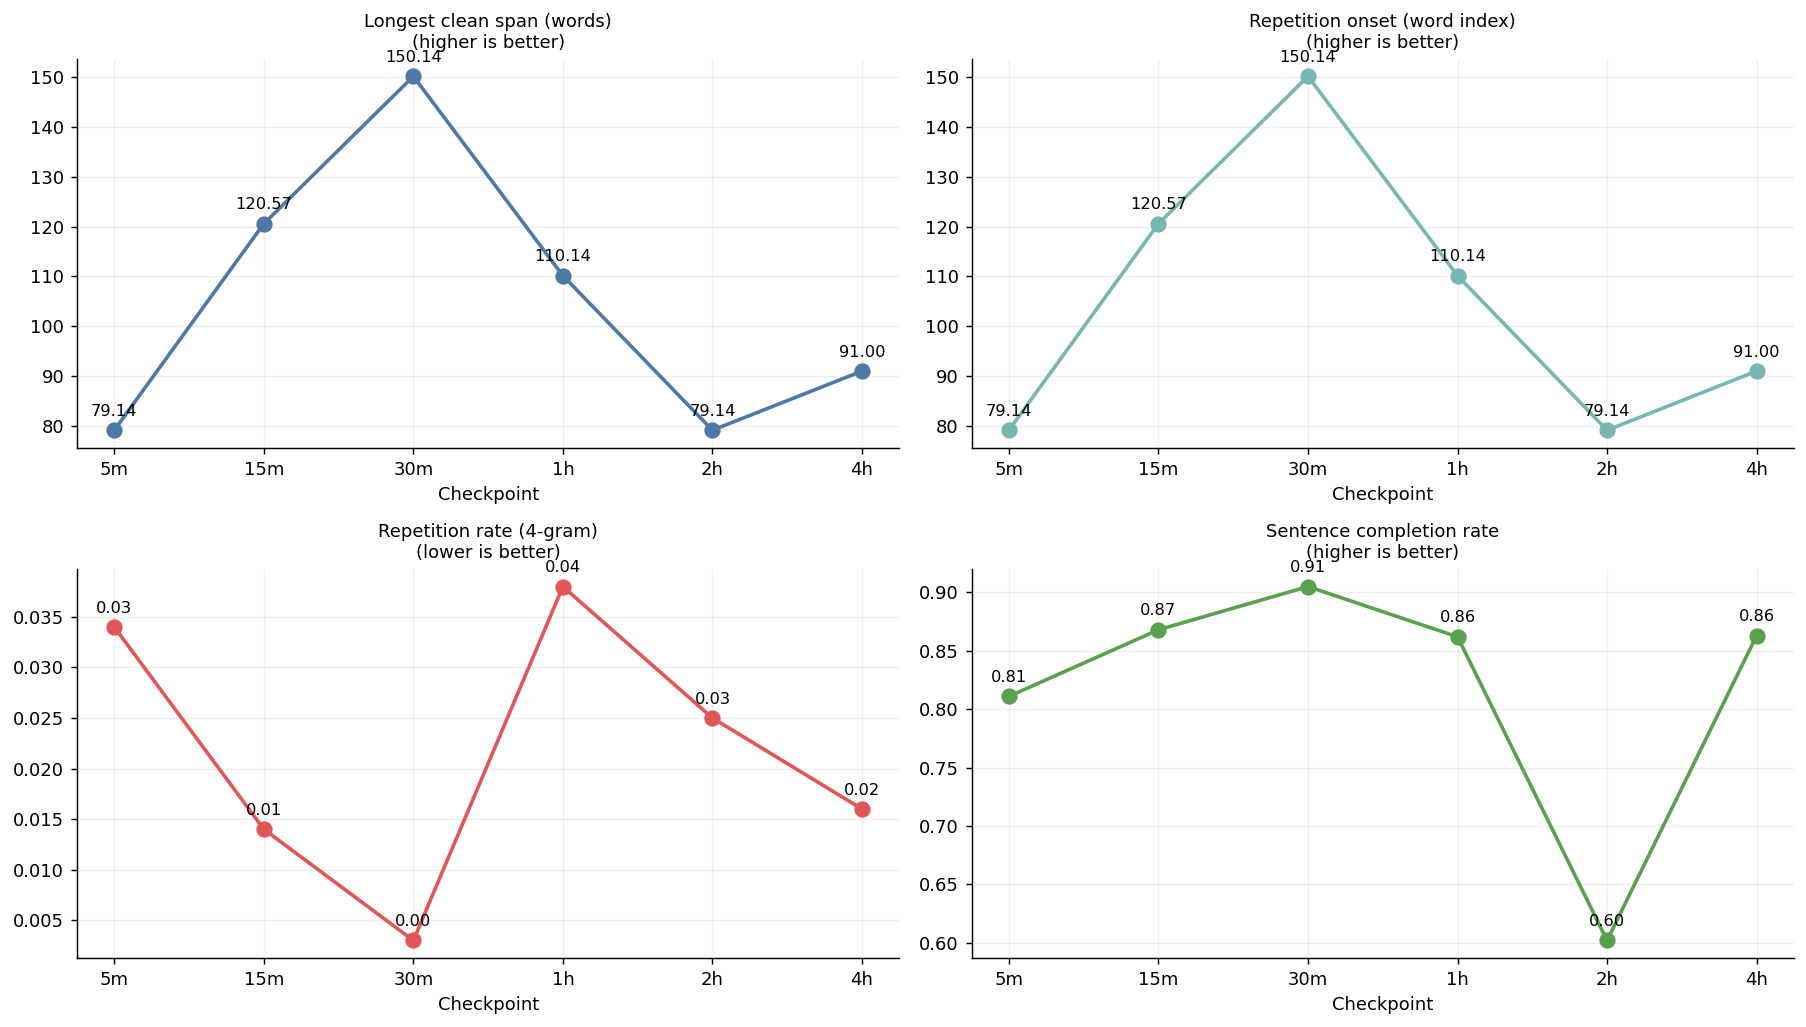

Saved output/text_metrics.png


In [8]:
def repetition_onset(text, ngram=4):
    """Word index of the first repeated n-gram. Returns None if no repetition."""
    words = text.lower().split()
    seen = {}
    for i in range(len(words) - ngram + 1):
        g = tuple(words[i : i + ngram])
        if g in seen:
            return i
        seen[g] = i
    return None


def longest_clean_span(text, ngram=4):
    """Number of words before the first repeated n-gram (= repetition_onset, or full length)."""
    onset = repetition_onset(text, ngram)
    words = text.split()
    return onset if onset is not None else len(words)


def repetition_rate(text, ngram=4):
    """Fraction of n-grams that are repeated."""
    words = text.lower().split()
    if len(words) < ngram + 1:
        return 0.0
    grams = [tuple(words[i : i + ngram]) for i in range(len(words) - ngram + 1)]
    return 1 - len(set(grams)) / len(grams)


def sentence_completion_rate(text):
    """Fraction of sentence-like units ending with . ! ? — proxy for syntactic tidiness."""
    units = re.split(r"(?<=[.!?])\s+", text.strip())
    if not units:
        return 0.0
    complete = sum(1 for u in units if re.search(r"[.!?]$", u.strip()))
    return complete / len(units)


def type_token_ratio(text):
    """Lexical diversity — length-dependent; use as directional signal only."""
    words = re.findall(r"\b\w+\b", text.lower())
    return len(set(words)) / len(words) if words else 0.0


def avg_sentence_length(text):
    sentences = re.split(r"[.!?]+", text)
    lengths = [len(s.split()) for s in sentences if s.strip()]
    return np.mean(lengths) if lengths else 0.0


# Compute metrics per label per prompt
metric_rows = []
for label in available_labels:
    for pname, text in prompt_data[label].items():
        onset = repetition_onset(text)
        metric_rows.append(
            {
                "label": label,
                "prompt": pname,
                "rep_onset_word": onset if onset is not None else len(text.split()),
                "clean_span": longest_clean_span(text),
                "rep_rate": round(repetition_rate(text), 4),
                "sent_completion": round(sentence_completion_rate(text), 3),
                "ttr": round(type_token_ratio(text), 4),
                "avg_sent_len": round(avg_sentence_length(text), 1),
            }
        )

if metric_rows:
    mdf = pd.DataFrame(metric_rows)
    summary = (
        mdf.groupby("label")[
            [
                "rep_onset_word",
                "clean_span",
                "rep_rate",
                "sent_completion",
                "ttr",
                "avg_sent_len",
            ]
        ]
        .mean()
        .round(3)
    )
    summary = summary.reindex([l for l in LABELS if l in summary.index])
    print("Mean across all prompts per checkpoint:")
    display(summary)

    # Plot: the four most diagnostic signals
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    plots = [
        ("clean_span", "Longest clean span (words)", "#4e79a7", "higher is better"),
        (
            "rep_onset_word",
            "Repetition onset (word index)",
            "#76b7b2",
            "higher is better",
        ),
        ("rep_rate", "Repetition rate (4-gram)", "#e15759", "lower is better"),
        ("sent_completion", "Sentence completion rate", "#59a14f", "higher is better"),
    ]
    for ax, (col, title, color, note) in zip(axes.flat, plots):
        ax.plot(
            summary.index,
            summary[col],
            marker="o",
            color=color,
            linewidth=2,
            markersize=8,
        )
        for x, y in zip(summary.index, summary[col]):
            ax.annotate(
                f"{y:.2f}",
                (x, y),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=9,
            )
        ax.set_title(f"{title}\n({note})", fontsize=10)
        ax.set_xlabel("Checkpoint")
        ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(RUN_DIR / "text_metrics.png", bbox_inches="tight")
    plt.show()
    print("Saved output/text_metrics.png")

## 7. Qualitative Scoring

Rate each checkpoint manually after reading the prompt outputs above.
Scales are defined in `program.md`.

| Prompt | Metric | 5m | 15m | 30m | 1h | 2h | 4h |
| --- | --- | --- | --- | --- | --- | --- | --- |
| plain_continuation | coherent span (1–5) | | | | | | |
| plain_continuation | syntax stability | | | | | | |
| plain_continuation | prompt adherence | | | | | | |
| factual_fragment | specificity vs sludge | | | | | | |
| factual_fragment | prompt adherence | | | | | | |
| longitudinal_anchor | coherent span (1–5) | | | | | | |
| longitudinal_anchor | specificity vs sludge | | | | | | |
| structurally_awkward | syntax stability | | | | | | |
| structurally_awkward | prompt adherence | | | | | | |
| anomaly_lure | weirdness retained | | | | | | |
| anomaly_lure | interestingness | | | | | | |
| signature | coherent span (1–5) | | | | | | |
| signature | repetition onset | | | | | | |
| continuation | coherent span (1–5) | | | | | | |
| continuation | prompt adherence | | | | | | |
| **ALL** | **overall interestingness** | | | | | | |"

## 8. Observations

Fill in after reviewing outputs and scoring above.

### Quantitative
- val_bpb: 5m ___ → 1h ___ → 4h ___
- Diminishing returns appear after: ___
- Train loss still falling at 4h? ___
- Clean span peaks at: ___
- Sentence completion rate changes noticeably at: ___

### Qualitative
- Surface fluency (syntax) improves noticeably at: ___
- Deeper coherence (span, adherence) improves at: ___
- Repetition loops first appear at: ___ worsen at: ___
- Weirdness retained through: ___ / collapses at: ___
- Most interesting output: checkpoint ___, prompt ___
- Something unexpected: ___

### Next questions
Run same framework on:
- another seed
- another warmdown ration
- slightly larger model

(see if the 30m sweet spot/2h slump replicates)